### This is the simple workflow with graph(phase 1)

In [1]:
import os

In [2]:
def function1(input1):
    return input1 + "from first function"

def function2(input2):
    return input2 + " and 123 from second function"

In [3]:
def function3(input3):
    return input3

In [ ]:
function1("Hello ")

'Hellofrom first function'

In [6]:
function2("hi ")

'hi  and 123 from second function'

In [7]:
def function1(input1):
    return input1 + "from first function"

def function2(input2):
    output=function3("this is function 3 in between")
    return input2 + " " + output + " and 123 from second function"

In [8]:

function1("Hello ") + " " + function2("hi ")

'Hello from first function hi  this is function 3 in between and 123 from second function'

DEPRECATED
```python
from langgraph.graph import Graph

workflow1 = Graph()
workflow1.add_node("function1"function1)
workflow1.add_node("function2"function2)
workflow1.set_entry_point("function1")
workflow1.set_finish_point("function2")
app1 = workflow1.compile()

from IPython.display import Image, display

try:
    display(Image(app1.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

app1.invoke("hi this is pragi ")

input = "hi this is pragi "

for output in app1.stream(input):
    for key, value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")
```

In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

# Minimal state schema — just a single string field
class SimpleState(TypedDict):
    data: str

# Rewrite nodes to accept/return state dict
def function1(state: SimpleState):
    return {"data": state["data"] + " from first function"}

def function2(state: SimpleState):
    output = function3("this is function 3 in between")
    return {"data": state["data"] + " " + output + " and Hi from second function"}

# Build graph — exact same structure, just different class + START/END
workflow1 = StateGraph(SimpleState)
workflow1.add_node("function1", function1)
workflow1.add_node("function2", function2)
workflow1.add_edge(START, "function1")
workflow1.add_edge("function1", "function2")
workflow1.add_edge("function2", END)
app1 = workflow1.compile()

# invoke — pass a dict now, get a dict back
result = app1.invoke({"data": "hi this is Hello "})
print(result["data"])

# stream — same loop as before
for output in app1.stream({"data": "hi this is Hello "}):
    for key, value in output.items():
        print(f"Output from {key}: {value}")

hi this is Hello  from first function this is function 3 in between and Hi from second function
Output from function1: {'data': 'hi this is Hello  from first function'}
Output from function2: {'data': 'hi this is Hello  from first function this is function 3 in between and Hi from second function'}


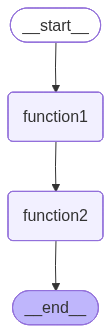

In [16]:
from IPython.display import Image, display

try:
    display(Image(app1.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

### phase 2

In [14]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [15]:
def function1(state: SimpleState):
    response = llm.invoke(state["data"]).content
    return {"data": response}

def function2(state: SimpleState):
    return {"data": state["data"].upper()}

workflow2 = StateGraph(SimpleState)
workflow2.add_node("llm", function1)
workflow2.add_node("upper_string", function2)
workflow2.add_edge(START, "llm")
workflow2.add_edge("llm", "upper_string")
workflow2.add_edge("upper_string", END)
app2 = workflow2.compile()

result = app2.invoke({"data": "what is the name of the first indian prime minister?"})
print(result["data"])

THE FIRST PRIME MINISTER OF INDIA WAS JAWAHARLAL NEHRU. HE SERVED AS THE PRIME MINISTER FROM AUGUST 15, 1947, TO MAY 27, 1964.


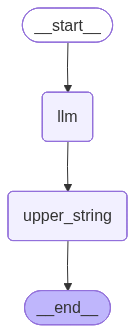

In [17]:
from IPython.display import Image, display

try:
    display(Image(app2.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [18]:
import os
os.makedirs("data2", exist_ok=True)

# Create sample text files so the RAG pipeline has something to retrieve
with open("data2/japan.txt", "w") as f:
    f.write("""Japan's industrial growth began in the Meiji era (1868-1912) when the government modernized the economy by importing Western technology and establishing factories. Japan became a major steel, shipbuilding, and textile producer. After World War II, Japan rebuilt rapidly and became the world's second-largest economy by the 1960s. Key industries include automobiles (Toyota, Honda), electronics (Sony, Panasonic), and robotics. Japan is known for the manufacturing philosophy of Kaizen (continuous improvement) and the Toyota Production System (lean manufacturing). Japan's GDP ranks third globally as of the 2020s.""")

with open("data2/sports.txt", "w") as f:
    f.write("""Sports play a significant role in Japanese culture. Baseball (yakyu) is the most popular professional sport in Japan, introduced in the 1870s. Japan has 12 professional baseball teams in the NPB league. Soccer (J-League) was founded in 1993 and has grown rapidly. Sumo is Japan's national sport with a history of over 1500 years. Japan hosted the Summer Olympics in 1964 (Tokyo) and again in 2020 (Tokyo). Japanese athletes excel in martial arts including judo, karate, and wrestling. The country also has strong traditions in table tennis, badminton, and swimming.""")

In [19]:
from dotenv import load_dotenv
load_dotenv()

import warnings
warnings.filterwarnings("ignore", message=".*langchain-community.*")

from langchain_groq import ChatGroq
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter  # fixed import

llm = ChatGroq(model="llama-3.3-70b-versatile")
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

loader = DirectoryLoader("data2", glob="./*.txt", loader_cls=TextLoader)
docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=50
)
new_docs = text_splitter.split_documents(documents=docs)
doc_strings = [doc.page_content for doc in new_docs]

db = Chroma.from_documents(new_docs, embeddings)
retriever = db.as_retriever(search_kwargs={"k": 3})

# test the retriever
query = "what is Japan's industrial growth?"
result_docs = retriever.invoke(query)          # fixed: was get_relevant_documents()
print(result_docs[0].metadata)
print(result_docs[0].page_content)

{'source': 'data2\\japan.txt'}
Japan's industrial growth began in the Meiji era (1868-1912) when the government modernized the


### phase 3

In [20]:
mydict = {}
mydict["messages"] = "hi, how are you?"
print("After first assign:", mydict)

mydict["messages"] = "hi, what are you doing?"
print("After second assign (overwrites!):", mydict)

# Now with a list — messages accumulate
AgentState = {}
AgentState["messages"] = []
AgentState["messages"].append("hi, how are you?")
AgentState["messages"].append("hi, what you doing?")

print("All messages:", AgentState)
print("Latest message:", AgentState["messages"][-1])

After first assign: {'messages': 'hi, how are you?'}
After second assign (overwrites!): {'messages': 'hi, what are you doing?'}
All messages: {'messages': ['hi, how are you?', 'hi, what you doing?']}
Latest message: hi, what you doing?


In [26]:
def function_1_phase3(state):
    message = state["messages"]
    question = message[-1]

    complete_prompt = (
        "Your task is to provide only the brief answer based on the user query. "
        "Don't include too much reasoning. Following is the user query: " + question
    )

    response = llm.invoke(complete_prompt)
    return {"messages": state["messages"] + [response.content]} 

In [27]:
def function_2_phase3(state):
    messages = state["messages"]
    question = messages[0]

    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """
    prompt = ChatPromptTemplate.from_template(template)

    retrieval_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )
    result = retrieval_chain.invoke(question)
    return {"messages": state["messages"] + [result]}  # fixed: was return result

In [28]:
class Phase3State(TypedDict):
    messages: list   # plain list, no reducer needed — function mutates in place

workflow4 = StateGraph(Phase3State)
workflow4.add_node("LLM", function_1_phase3)
workflow4.add_node("RAGtool", function_2_phase3)
workflow4.add_edge(START, "LLM")
workflow4.add_edge("LLM", "RAGtool")
workflow4.add_edge("RAGtool", END)
app4 = workflow4.compile()

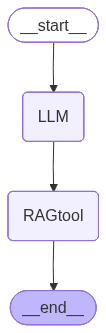

In [29]:
from IPython.display import Image, display

try:
    display(Image(app4.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [30]:
inputs = {"messages": ["Tell me about llama3 model efficiency"]}
result = app4.invoke(inputs)
print(result)

{'messages': ['Tell me about llama3 model efficiency', 'Llama3 model efficiency: 1.3-4x more efficient than Llama2, 2.5-7.5x more efficient than other large language models.', 'There is no information about the "llama3 model efficiency" in the provided context. The context only discusses Japan\'s manufacturing philosophy, including Kaizen and the Toyota Production System (lean manufacturing), as well as its GDP ranking.']}


### phase 4

In [31]:
from typing import TypedDict, Annotated, Sequence
import operator
from langchain_core.messages import BaseMessage
from langchain_core.prompts import PromptTemplate     # fixed: was langchain.prompts
from pydantic import BaseModel, Field                 # already correct
from langchain_core.output_parsers import PydanticOutputParser  # fixed: was langchain.output_parsers

In [32]:
print(operator.add(10, 15))   # 25 — for numbers, adds them
print(operator.sub(10, 15))   # -5

# For lists, operator.add CONCATENATES — this is what StateGraph uses
print(operator.add(["msg1"], ["msg2"]))  # ["msg1", "msg2"]

25
-5
['msg1', 'msg2']


In [33]:
from langgraph.graph import add_messages   # modern best practice

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

In [34]:
from pydantic import BaseModel, Field, ValidationError

class TopicSelectionParser(BaseModel):
    Topic: str = Field(description="Selected Topic")
    Reasoning: str = Field(description="Reasoning behind topic selection")

# Valid data
data = {
    "Topic": "Artificial Intelligence",
    "Reasoning": "It's a rapidly growing field with many advancements."
}
try:
    parsed = TopicSelectionParser(**data)
    print(parsed.Topic)
    print(parsed.Reasoning)
except ValidationError as e:
    print(e)

# Invalid data — Pydantic coerces int→str in v2, so no error here
# but it shows the validation system
invalid_data = {"Topic": "Artificial Intelligence", "Reasoning": 12345}
try:
    parsed = TopicSelectionParser(**invalid_data)
    print(parsed.Reasoning)   # Pydantic v2 coerces 12345 → "12345"
except ValidationError as e:
    print(e)

Artificial Intelligence
It's a rapidly growing field with many advancements.
1 validation error for TopicSelectionParser
Reasoning
  Input should be a valid string [type=string_type, input_value=12345, input_type=int]
    For further information visit https://errors.pydantic.dev/2.13/v/string_type


In [35]:
from langchain_core.output_parsers import PydanticOutputParser  # fixed import

parser = PydanticOutputParser(pydantic_object=TopicSelectionParser)
print(parser.get_format_instructions())


The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"properties": {"Topic": {"description": "Selected Topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}
```


In [36]:
loader2 = DirectoryLoader("data2", glob="./*.txt", loader_cls=TextLoader)
docs2 = loader2.load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=50)
new_docs2 = text_splitter.split_documents(documents=docs2)

db2 = Chroma.from_documents(new_docs2, embeddings)
retriever = db2.as_retriever(search_kwargs={"k": 3})   # overwrites retriever from Phase 3

test_docs = retriever.invoke("Tell me about Japan's Industrial Growth?")  # fixed
print(test_docs[0].metadata)
print(test_docs[0].page_content)

{'source': 'data2\\japan.txt'}
Japan's industrial growth began in the Meiji era (1868-1912) when the government modernized the


In [48]:
def function_1(state):
    messages = state["messages"]
    question = messages[-1].content if hasattr(messages[-1], "content") else messages[-1]
    print("Classifying:", question)

    template = """
    Your task is to classify the given user query into one of the following categories: [Japan, Sports, Not Related].
    Only respond with the category name and nothing else.

    User query: {question}
    {format_instructions}
    """

    prompt = PromptTemplate(
        template=template,
        input_variables=["question"],          # fixed: was [question] (variable value, not name)
        partial_variables={
            "format_instructions": parser.get_format_instructions()
        }
    )

    chain = prompt | llm | parser
    response = chain.invoke({
        "question": question,
        "format_instructions": parser.get_format_instructions()
    })

    print("Classification result:", response)
    return {"messages": [response.Topic]}

In [49]:
state = {"messages": ["Tell me about Japan's Industrial Growth"]}
result = function_1(state)
print(result)

Classifying: Tell me about Japan's Industrial Growth
Classification result: Topic='Japan' Reasoning='The user query mentions Japan, indicating the topic is related to Japan'
{'messages': ['Japan']}


In [50]:
def function_2(state):
    print("-> Calling RAG ->")
    messages = state["messages"]
    question = messages[0].content if hasattr(messages[0], "content") else messages[0]


    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """
    prompt = ChatPromptTemplate.from_template(template)

    retrieval_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
    )
    result = retrieval_chain.invoke(question)
    return {"messages": [result]}

In [51]:
def function_3(state):
    print("-> Calling LLM ->")
    messages = state["messages"]
    question = messages[0].content if hasattr(messages[0], "content") else messages[0]


    complete_query = (
        "Answer the following question with your knowledge of the real world. "
        "Following is the user question: " + question
    )
    response = llm.invoke(complete_query)
    return {"messages": [response.content]}

In [52]:
def router(state):
    print("-> Router ->")
    messages = state["messages"]

    last = messages[-1]
    last_message = last.content if hasattr(last, "content") else last
    print("Routing based on:", last_message)
    
    if "Japan" in last_message or "Sports" in last_message:
        return "RAG Call"
    else:
        return "LLM Call"

In [53]:
from langgraph.graph import StateGraph, START, END

workflow5 = StateGraph(AgentState)
workflow5.add_node("agent", function_1)
workflow5.add_node("RAG", function_2)
workflow5.add_node("LLM", function_3)

workflow5.add_edge(START, "agent")             # fixed: was set_entry_point()

workflow5.add_conditional_edges(
    "agent",
    router,
    {
        "RAG Call": "RAG",
        "LLM Call": "LLM",
    }
)

workflow5.add_edge("RAG", END)
workflow5.add_edge("LLM", END)

app5 = workflow5.compile()

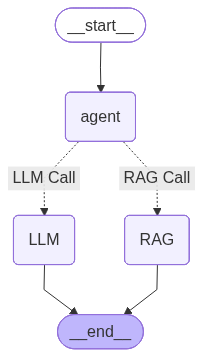

In [43]:
from IPython.display import Image, display

try:
    display(Image(app5.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [54]:
inputs = {"messages": ["Tell me about Japan's Industrial Growth"]}
output = app5.invoke(inputs)
print(output)

Classifying: Tell me about Japan's Industrial Growth
Classification result: Topic='Japan' Reasoning='The user query mentions Japan, indicating the topic is related to Japan'
-> Router ->
Routing based on: Japan
-> Calling RAG ->
{'messages': [HumanMessage(content="Tell me about Japan's Industrial Growth", additional_kwargs={}, response_metadata={}, id='2108a39a-c384-47ee-8ed0-a92be2347b7a'), HumanMessage(content='Japan', additional_kwargs={}, response_metadata={}, id='b0c34367-02a7-417d-8d3e-f42fc922c786'), HumanMessage(content="Japan's industrial growth began in the Meiji era (1868-1912) when the government modernized the economy by importing Western technology and establishing factories. As a result, Japan became a major steel producer.", additional_kwargs={}, response_metadata={}, id='85e2c7a4-5217-41a7-84b6-0b9e84451985')]}


In [55]:
inputs = {"messages": ["Tell me about the first prime minister of india?"]}
output = app5.invoke(inputs)
print(output)

Classifying: Tell me about the first prime minister of india?
Classification result: Topic='Not Related' Reasoning='The query is about the first prime minister of India, which does not relate to Japan or sports.'
-> Router ->
Routing based on: Not Related
-> Calling LLM ->
{'messages': [HumanMessage(content='Tell me about the first prime minister of india?', additional_kwargs={}, response_metadata={}, id='97805387-6ac4-41b7-a173-f77eb4f3df21'), HumanMessage(content='Not Related', additional_kwargs={}, response_metadata={}, id='3f092a0f-f29b-469e-af8b-b817262b224c'), HumanMessage(content="The first Prime Minister of India was Jawaharlal Nehru. He was born on November 14, 1889, in Allahabad, India, and died on May 27, 1964. Nehru was a key figure in India's struggle for independence from British rule and played a crucial role in shaping the country's future.\n\nNehru became the first Prime Minister of India on August 15, 1947, when India gained independence from Britain. He served as Pri

### phase 5

In [56]:
import json
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

In [57]:
@tool
def multiply(first_number: int, second_number: int):
    """Multiplies two numbers together."""
    return first_number * second_number

print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Multiplies two numbers together.
{'first_number': {'title': 'First Number', 'type': 'integer'}, 'second_number': {'title': 'Second Number', 'type': 'integer'}}


In [58]:
model_with_tools = llm.bind_tools([multiply])

In [59]:
response = model_with_tools.invoke("What is 35 * 46?")
print(response)
print()
print("type:", type(response))

content='' additional_kwargs={'tool_calls': [{'id': 'qd1eqnbnj', 'function': {'arguments': '{"first_number":35,"second_number":46}', 'name': 'multiply'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 228, 'total_tokens': 249, 'completion_time': 0.06582102, 'completion_tokens_details': None, 'prompt_time': 0.012763239, 'prompt_tokens_details': None, 'queue_time': 0.041915718, 'total_time': 0.078584259}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ba38bbab80', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019effe4-af29-7162-9d05-9ed7cd584e51-0' tool_calls=[{'name': 'multiply', 'args': {'first_number': 35, 'second_number': 46}, 'id': 'qd1eqnbnj', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 228, 'output_tokens': 21, 'total_tokens': 249}

type: <class 'langchain_core.messages.ai.AIMessage'>


In [60]:
print("Via response.tool_calls (modern):")
print(response.tool_calls)
# → [{'name': 'multiply', 'args': {'first_number': 35, 'second_number': 46}, 'id': '...', 'type': 'tool_call'}]

print()
print("Name :", response.tool_calls[0]["name"])
print("Args :", response.tool_calls[0]["args"])
print("ID   :", response.tool_calls[0]["id"])

# OLD way still works but is verbose — shown here just for comparison
print("\nVia additional_kwargs (old, avoid):")
print(response.additional_kwargs.get("tool_calls"))

Via response.tool_calls (modern):
[{'name': 'multiply', 'args': {'first_number': 35, 'second_number': 46}, 'id': 'qd1eqnbnj', 'type': 'tool_call'}]

Name : multiply
Args : {'first_number': 35, 'second_number': 46}
ID   : qd1eqnbnj

Via additional_kwargs (old, avoid):
[{'id': 'qd1eqnbnj', 'function': {'arguments': '{"first_number":35,"second_number":46}', 'name': 'multiply'}, 'type': 'function'}]


In [61]:
# Using add_messages (modern) instead of Annotated[Sequence[BaseMessage], operator.add]
# add_messages handles HumanMessage / AIMessage / ToolMessage deduplication by ID
# This matters in Phase 5 — ToolMessage must be linked to a tool call by ID

from typing import TypedDict, Annotated
from langgraph.graph import add_messages

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

In [62]:
def invoke_model(state):
    messages = state["messages"]
    response = model_with_tools.invoke(messages)  # pass full history, not just last message
    return {"messages": [response]}               # AIMessage goes into state

In [63]:
def invoke_tool(state):
    last_message = state["messages"][-1]          # AIMessage with tool_calls
    tool_calls = last_message.tool_calls          # modern: clean list of dicts

    print(f"Tool calls received: {tool_calls}")

    multiply_call = None
    for tc in tool_calls:
        if tc["name"] == "multiply":
            multiply_call = tc

    if multiply_call is None:
        raise Exception("No multiply tool call found.")

    # Execute the tool with parsed args — no json.loads() needed
    result = multiply.invoke(multiply_call["args"])
    print(f"Tool result: {result}")

    # Return a ToolMessage — must include tool_call_id to link back to the AIMessage
    return {
        "messages": [
            ToolMessage(
                content=str(result),
                tool_call_id=multiply_call["id"],
            )
        ]
    }

In [64]:
workflow6 = StateGraph(AgentState)
workflow6.add_node("agent", invoke_model)
workflow6.add_node("tool", invoke_tool)

workflow6.add_edge(START, "agent")      # fixed: was set_entry_point()
workflow6.add_edge("tool", END)

# Router reads tool_calls from the modern response.tool_calls field
def router(state):
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and len(last_message.tool_calls):
        return "multiply"
    else:
        return "end"

workflow6.add_conditional_edges(
    "agent",
    router,
    {
        "multiply": "tool",
        "end": END,
    }
)

app6 = workflow6.compile()

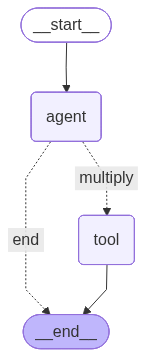

In [65]:
from IPython.display import Image, display

try:
    display(Image(app6.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [66]:
output = app6.invoke({"messages": ["What is 123 * 456?"]})

for msg in output["messages"]:
    print(type(msg).__name__, ":", msg.content)

print("\nFinal answer:", output["messages"][-1].content)   # → 56088

Tool calls received: [{'name': 'multiply', 'args': {'first_number': 123, 'second_number': 456}, 'id': 'c6e7f7ge4', 'type': 'tool_call'}]
Tool result: 56088
HumanMessage : What is 123 * 456?
AIMessage : 
ToolMessage : 56088

Final answer: 56088


In [67]:
output = app6.invoke({"messages": ["What is LLM?"]})

for msg in output["messages"]:
    print(type(msg).__name__, ":", msg.content[:80])

print("\nFinal answer:", output["messages"][-1].content)

HumanMessage : What is LLM?
AIMessage : LLM stands for Large Language Model. It refers to a type of artificial intellige

Final answer: LLM stands for Large Language Model. It refers to a type of artificial intelligence (AI) designed to process and understand human language. LLMs are trained on vast amounts of text data, which enables them to generate coherent and context-specific text, answer questions, and even engage in conversation. They are a key component of many natural language processing (NLP) applications, including chatbots, language translation software, and text summarization tools.


In [68]:
input1 = {"messages": ["What is 123 * 456?"]}

for chunk in app6.stream(input1):
    for key, value in chunk.items():
        print(f"Output from '{key}':")
        print("_______")
        for msg in value["messages"]:
            print(f"  [{type(msg).__name__}] {msg.content}")
        print()

Output from 'agent':
_______
  [AIMessage] 

Tool calls received: [{'name': 'multiply', 'args': {'first_number': 123, 'second_number': 456}, 'id': '1y45xbj17', 'type': 'tool_call'}]
Tool result: 56088
Output from 'tool':
_______
  [ToolMessage] 56088

